# Test bench for neutrino integration in the background


### Imports

In [1]:
# Import modules
from matplotlib import pyplot as plt
from mpmath import zeta, pi
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
import jax.numpy as jnp
from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)



0.9.1


### Parameters to save plot (to run only if plot need to be saved)

In [113]:
mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
})

### Reset plot parameter (to allow plt.show)

In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

### Simulation settings
DISCO-DJ can be run on a GPU (*much* faster) or on a CPU. The following cell detects if a GPU is available and sets the device accordingly.

In [3]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"

# We first want to compute the neutrino energy density parameter

### Gauss-Laguerre coeff function 

In [4]:
def generalized_gauss_laguerre_weights(n, alpha):
    """
    Compute nodes and weights for n-point generalized Gauss-Laguerre quadrature,
    which approximates integrals of the form
        ∫₀∞ x^α f(x) e^(-x) dx.
    
    Parameters:
        n : int
            Number of quadrature points.
        alpha : float
            The parameter in the weight function x^α e^(-x).
    
    Returns:
        nodes : ndarray
            The quadrature nodes (abscissae).
        weights : ndarray
            The quadrature weights.
    """
    # Indices i = 1, 2, ..., n.
    i = jnp.arange(1, n+1)
    
    # Diagonal entries: a_i = 2i - 1 + alpha.
    a = 2*i - 1 + alpha
    
    # Off-diagonal entries for i = 1, ..., n-1: b_i = sqrt(i*(i+alpha))
    i_off = jnp.arange(1, n)
    b = jnp.sqrt(i_off * (i_off + alpha))
    
    # Construct the symmetric tridiagonal Jacobi matrix.
    J = jnp.diag(a) + jnp.diag(b, 1) + jnp.diag(b, -1)
    
    # Compute eigenvalues (nodes) and eigenvectors.
    nodes, V = jnp.linalg.eigh(J)
    
    # The weights are given by the square of the first component of the eigenvectors,
    # multiplied by the zeroth moment: Γ(α+1).
    if type(alpha) == int:
      weights = (V[0, :]**2) * jax.scipy.special.factorial(alpha)
    else:
      weights = (V[0, :]**2) * jax.scipy.special.gamma(alpha + 1)
    
    return nodes, weights

### Neutrinos momentum bins and energy density 

In [5]:
def get_neutrino_momentum_bins(  nqmax : int ) -> tuple[jax.Array, jax.Array]:
    """Get the momentum bins and integral kernel weights for neutrinos

    Args:
        nqmax (int): Number of momentum bins.

    Returns:
        jax.Array: q, w
    """
    # fermi_dirac_const = 7 * np.pi**4 / 120
    #fermi_dirac_const = 5.682196976983475

    # nqmax = 3,4,5 are from high accuracy formulas from CAMB, higher values resort to modified Gauss-Laguerre, 
    # which is not pre-computed however
    if nqmax == 3:
        q = jnp.array([0.913201, 3.37517, 7.79184])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0687359, 3.31435, 2.29911]) / (-0.25*dlfdlq)
    elif nqmax == 4:
        q = jnp.array([0.7, 2.62814, 5.90428, 12.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0200251, 1.84539, 3.52736, 0.289427]) / (-0.25*dlfdlq)
    elif nqmax == 5:
        q = jnp.array([0.583165, 2.0, 4.0, 7.26582, 13.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0081201, 0.689407, 2.8063, 2.05156, 0.12681]) / (-0.25*dlfdlq)
    else:
        alpha = 1
        q, w = generalized_gauss_laguerre_weights( nqmax, alpha )
        w *= q**3 / (1 + jnp.exp(-q)) * q**-alpha
    
    return q, w 


def nu_background( a : float, amnu: float, nq : int = 8 ) -> tuple[float, float, float]:
    """ computes the neutrino density and pressure of one flavour of massive neutrinos
        in units of the mean density of one flavour of massless neutrinos

    Args:
        a (float): scale factor
        amnu (float): neutrino mass in units of neutrino temperature (m_nu*c**2/(k_B*T_nu0).
        nq (int, optional): number of integration points. Defaults to 8.

    Returns:
        tuple[float, float, float]: rho_nu/rho_nu0, p_nu/p_nu0, pp_nu/pp_nu0
    """
    
    # q is the comoving momentum in units of k_B*T_nu0/c.
    v    = lambda q: 1 / jnp.sqrt(1 + (a * amnu / q)**2)   # = (1/aq) / sqrt(1+1/aq**2)
    
    q, w = get_neutrino_momentum_bins( nq )
    rhonu = jnp.dot( w, 1. / v(q) )
    pnu = jnp.dot( w, v(q) / 3 )
    ppnu = jnp.dot( w, v(q)**3 / 3 )
    
    return rhonu, pnu, ppnu


### Neutrino and cosmological parameters

In [6]:
mnu = 0.06  # neutrio mass 
Tcmb = 2.725  #  CMB temp (K)
Tnu0 = (4/11)**(1/3)*Tcmb 
conKeV = 1.160451812e4  # conversion K/eV : 
amnu = mnu * conKeV / Tnu0 # parameter amnu pour nu_background 
h = 0.72 # dimensionless Hubble const 
g=2 # DoF
conv_ev3_to_cm3 = (5.0677307e4)**3  # conversion eV3 / cm3
rho_c = 10.54e3 * h**2 / conv_ev3_to_cm3   # 4.2e-11(eV4)
print(rho_c)

4.1982183126519246e-11


### Plot rho_nu(log a)

n_nu0_Th(cm-3) = 111.9547742544
n_nu0 (cm-3) = 111.95784


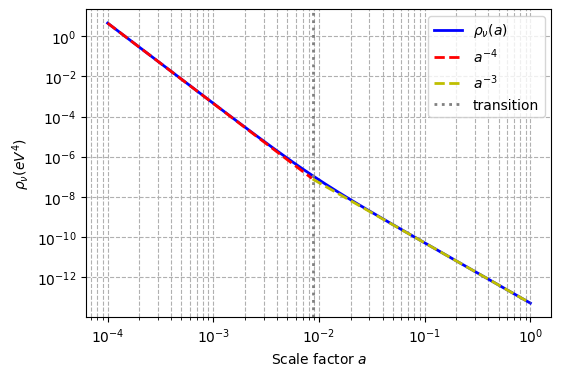

In [7]:
# scale factor array
a = jnp.geomspace(1e-4, 1.0, 500)

# neutrino density rho_nu(a)
rho_nu = jax.vmap(lambda aa: nu_background(aa, amnu)[0])(a)

# Transfo ev4
rho_nu = rho_nu * g * (Tnu0/conKeV)**4 / 2 / jnp.pi**2 / a**4

# Density of neutrinos today 
rho0 = rho_nu[-1]  
n_nu0 = rho0 / mnu * conv_ev3_to_cm3
n_nu0_th = g * (3 * zeta(3) / (4 * pi**2)) * (Tnu0/conKeV)**3 * conv_ev3_to_cm3
print("n_nu0_Th(cm-3) =", n_nu0_th)
print("n_nu0 (cm-3) =", n_nu0)


#  Reference lines 
rho_ref_a4 = rho_nu[0] * (a / a[0])**(-4)  
rho_ref_a3 = rho_nu[-1] * (a / a[-1])**(-3)  

diff = rho_ref_a4 - rho_ref_a3
cross_indices = jnp.where(diff[:-1] * diff[1:] < 0)[0]
idx_cross = cross_indices[0]
a_cross = a[idx_cross]


# Plot 
plt.figure(figsize=(6,4))
plt.loglog(a, rho_nu,color='blue', label=r'$\rho_\nu(a)$',lw=2)  
plt.loglog(a[:idx_cross], rho_ref_a4[:idx_cross], 'r--', label=r'$a^{-4}$',lw=2)  
plt.loglog(a[idx_cross:], rho_ref_a3[idx_cross:], 'y--', label=r'$a^{-3}$',lw=2)  
plt.axvline(a_cross, color='grey', linestyle=':', label=r'transition',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$\rho_\nu (eV^4)$')
#plt.title('Massive neutrino density as a function of scale factor')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
#plt.savefig('rhonu.pgf')

We should observe : 

- rho(0)/mnu approx= 112 per flavor (here one)
- rho -> a-4 for HR
- rho -> a-3 for NR
- Transition after T = 0.06 eV -> a = 3*10-3


# Computation of Omega 


Omega_nu(a=1) = 0.0012294198
Omega_nu(a=1) formule Th =  0.001231284475965327


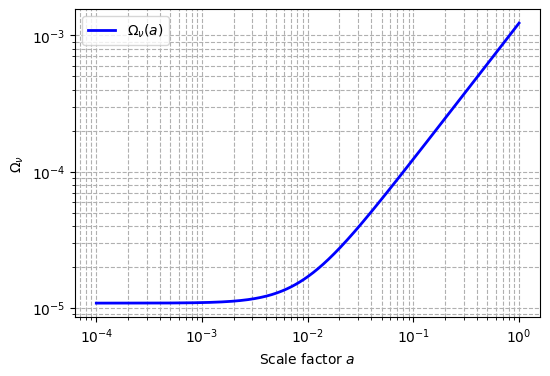

In [8]:
#Omega
Omega_nu = rho_nu *a**(4) / rho_c  

#Omega comparaisom sim / theory
Omega_nu0 = Omega_nu[-1]
print("Omega_nu(a=1) =", Omega_nu[-1])
print("Omega_nu(a=1) formule Th = " , mnu / 94 / 0.72**2)

#Plot
plt.figure(figsize=(6,4))
plt.loglog(a, Omega_nu,color='blue', label=r'$\Omega_\nu(a)$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$\Omega_\nu$')
#plt.title('cosmological density parameter for neutrino as a function of scale factor')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
#plt.savefig('omega.pgf')

# Equation of H


### Cosmology 

In [9]:
Omega_c=0.2589
Omega_b=0.04860
Omega_k=0.0
h=0.6774
n_s=0.9667
sigma8=0.8159
w0=-1.0
wa=0.0
H0=70

### Functions 

In [11]:
def Omega_nu(a):
    """Compute the neutrino density parameter."""
    return nu_background(a, amnu)[0] * g * (Tnu0/conKeV)**4 / (2 * jnp.pi**2 * rho_c) / a**4

########

def Omega_de(Omega_c , Omega_b ,Omega_k):
    """Compute the dark energy density parameter without neutrino."""
    return 1.0 - Omega_c - Omega_b - Omega_k 

def Omega_de_wnu(Omega_c , Omega_b ,Omega_k):
    """Compute the dark energy density parameter with neutrinos."""
    return 1.0 - Omega_c - Omega_b - Omega_k - Omega_nu(1)

########

def Omega_de_of_a(Omega_de, w0 ,wa, a):
    """Dark energy density term as a function of scale factor."""
    return Omega_de * (a ** (-3 * (1 + w0 + wa)) * jnp.exp(-3 * wa * (1 - a)))

########

#Inital Dark energy density parameter without/with neutrinos
Omega_de0 = Omega_de(Omega_c , Omega_b ,Omega_k)
Omega_de0_wnu = Omega_de_wnu(Omega_c , Omega_b ,Omega_k)

#Initial photon density parameter
Omega_gamma_0 = 2.47e-5 / h**2

########

def Hubble_const (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameterwithout neutrinos"""
    return H0 *jnp.sqrt( (Omega_gamma_0 *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0, w0 ,wa, a)) )

def Hubble_const_wnu (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameter with neutrinos"""
    return H0 * jnp.sqrt( (Omega_gamma_0 *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0_wnu, w0 ,wa, a) + Omega_nu(a)) )


### Computation 

In [12]:
#Computation of Hubble constant H without and with neutrinos 
H = Hubble_const(Omega_c , Omega_b ,Omega_k, a)
H_wnu = jnp.array([Hubble_const_wnu(Omega_c, Omega_b, Omega_k, ai) for ai in a])

### Plot of H

<Figure size 640x480 with 0 Axes>

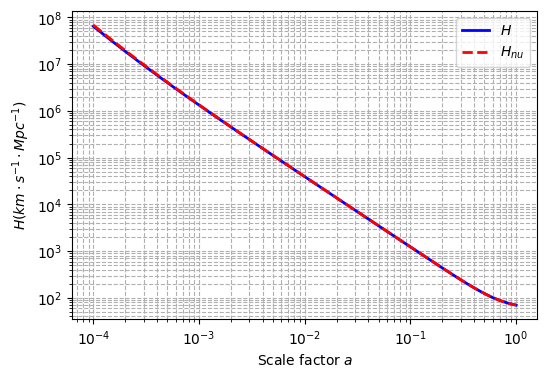

<Figure size 640x480 with 0 Axes>

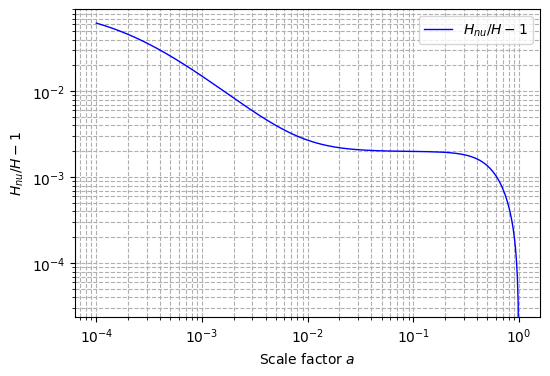

H0(a=1) 70.00189


In [14]:
#Plot H vs H_wnu
plt.figure(figsize=(6,4))
plt.loglog(a, H,color='blue', label=r'$H$',lw=2)  
plt.loglog(a, H_wnu,'r--', label=r'$H_{nu}$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H (km \cdot s^{-1} \cdot Mpc^{-1}$)')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
plt.savefig('H.pgf')


#Plot difference [(H_wnu/H)-1]
plt.figure(figsize=(6,4))
plt.loglog(a, abs(H_wnu/H -1),color='blue', label=r'$H_{nu}/H -1 $',lw=1)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{nu}/H -1 $')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
plt.savefig('Hdiff.pgf')

#Print conpute Hubble const today (to be compared with theoretical value fixed in cosmology)
print('H0(a=1)',H[-1])

### Equation of D

In [18]:
Omega_cb0 = Omega_c + Omega_b
f_nu = Omega_nu0 / (Omega_cb0 + Omega_nu0)

########

def E2(a):
    """Computation of E^2 without neutrinos"""
    return (Omega_gamma_0 * a**(-4)
    +Omega_cb0 * a**(-3)
    +Omega_k * a**(-2)
    +Omega_de_of_a(Omega_de0, w0, wa, a))


def E2_nu(a):
    """Computation of E^2 with neutrinos"""
    return (Omega_gamma_0 * a**(-4)
    +Omega_cb0 * a**(-3)
    +Omega_k * a**(-2)
    +Omega_de_of_a(Omega_de0_wnu, w0, wa, a)
    +Omega_nu(a))

########

def fdE_da(a):
    """Computation of dE/da without neutrinos"""
    dE2 = (
        -4 * Omega_gamma_0 * a**(-5)
        -3 * Omega_cb0 * a**(-4)
        -2 * Omega_k * a**(-3)
        + jax.grad(lambda x: Omega_de_of_a(Omega_de0, w0, wa, x))(a)
    )
    return 0.5 * dE2 / jnp.sqrt(E2(a))

def fdE_da_nu(a):
    """Computation of dE/da with neutrinos"""
    dE2 = (
        -4 * Omega_gamma_0 * a**(-5)
        -3 * Omega_cb0 * a**(-4)
        -2 * Omega_k * a**(-3)
        + jax.grad(lambda x: Omega_de_of_a(Omega_de0_wnu, w0, wa, x))(a)
        + jax.grad(Omega_nu)(a)
    )

    return 0.5 * dE2 / jnp.sqrt(E2_nu(a))

########

def growth_ode(a, y):
    """ODE of the growth function without neutrinos"""
    D, Dp = y

    E = jnp.sqrt(E2(a))

    dE_da = fdE_da(a)

    Omega_cb_a = (Omega_cb0 * a**(-3)) / E2(a)  
    source = (3/2) * (Omega_cb_a / a**2)

    Dpp = - (3/a + dE_da/E) * Dp + source * D
    return jnp.array([Dp, Dpp])

def growth_ode_nu(a, y):
    """ODE of the growth function with neutrinos"""
    D, Dp = y

    E = jnp.sqrt(E2_nu(a))

    dE_da = fdE_da_nu(a)

    Omega_cb_a = (Omega_cb0 * a**(-3)) / E2_nu(a)  

    source = (3/2) * (Omega_cb_a / a**2)

    Dpp = - (3/a + dE_da/E) * Dp + source * D
    return jnp.array([Dp, Dpp])

########

def rk4_step(f, a, y, da):
    k1 = f(a, y)
    k2 = f(a + da/2, y + da*k1/2)
    k3 = f(a + da/2, y + da*k2/2)
    k4 = f(a + da, y + da*k3)
    return y + (da/6)* (k1 + 2*k2 + 2*k3 + k4)

########

def integrate_growth(a_array, ode_func):
    """Computation of the ODE of the growth function D with RK4"""
    y = jnp.array([a_array[0], 1.0])  # D ~ a, D' ~ 1 au début
    ys = [y]

    for i in range(len(a_array)-1):
        a = a_array[i]
        da = a_array[i+1] - a
        y = rk4_step(ode_func, a, y, da)
        ys.append(y)

    return jnp.stack(ys)

### Computation of D (slow bc brute rk4)

In [19]:
#Computtion of the growth function without and with neutrinos
sol = integrate_growth(a, growth_ode)
sol_nu = integrate_growth(a, growth_ode_nu)

#Normalisation
D = sol[:, 0]
D_nu = sol_nu[:, 0]

### Plots of D

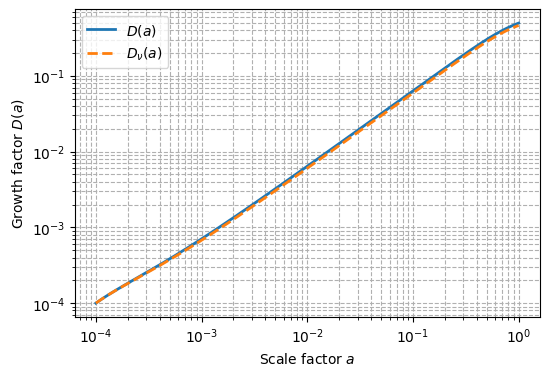

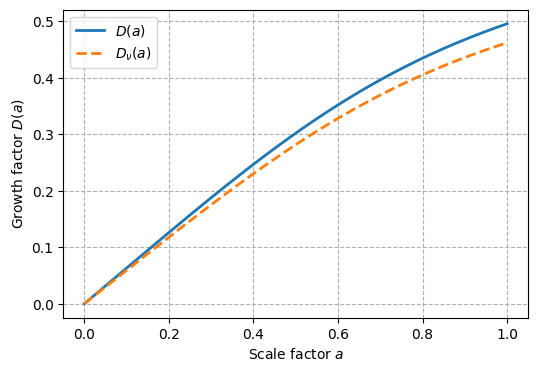

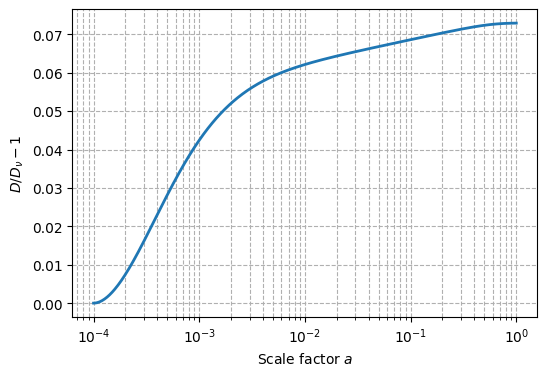

In [20]:
#Plot D vs D_nu
plt.figure(figsize=(6,4))
plt.loglog(a, D, label=r'$D(a)$', lw=2)
plt.loglog(a, D_nu, '--', label=r'$D_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

#Plot D vs D_nu
plt.figure(figsize=(6,4))
plt.plot(a, D, label=r'$D(a)$', lw=2)
plt.plot(a, D_nu, '--', label=r'$D_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

#Plot [(D/D_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, D/D_nu - 1, lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D/D_\nu - 1$')
plt.grid(True, which='both', ls='--')
plt.show()